In [1]:
import os
from google.colab import files

# 1. Create the folder structure required by the assignment
os.makedirs('/content/part_a', exist_ok=True)
os.makedirs('/content/data', exist_ok=True)

# 2. Upload your CSV files from your computer
print("Please upload q1_heart_disease.csv, q2_customers.csv, and q3_retail_promotions.csv:")
uploaded = files.upload()

# 3. Move the uploaded files into the 'data' folder
for filename in uploaded.keys():
    os.rename(filename, f"/content/data/{filename}")

# 4. Change the working directory to 'part_a'
# This is crucial so that '../data/' points to the correct location
os.chdir('/content/part_a')
print("\nEnvironment setup complete. You are now working inside 'part_a'.")

Please upload q1_heart_disease.csv, q2_customers.csv, and q3_retail_promotions.csv:


Saving q2_customers.csv to q2_customers.csv

Environment setup complete. You are now working inside 'part_a'.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Data Preparation
df_cust = pd.read_csv('../data/q2_customers.csv')
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_cust)

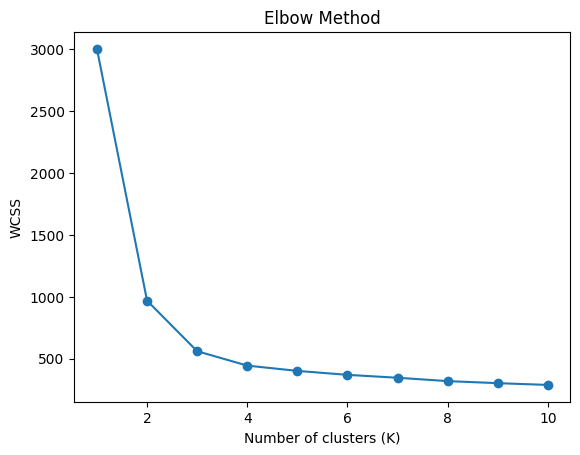

In [4]:
# 2. Choosing K (Elbow Method)
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.show()

In [5]:
# 3. K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cust['cluster'] = kmeans.fit_predict(scaled_data)

# Centroids
centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=df_cust.columns[:-1])
display(centroids)

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Explained Variance Ratio: [0.83560354 0.05568764]


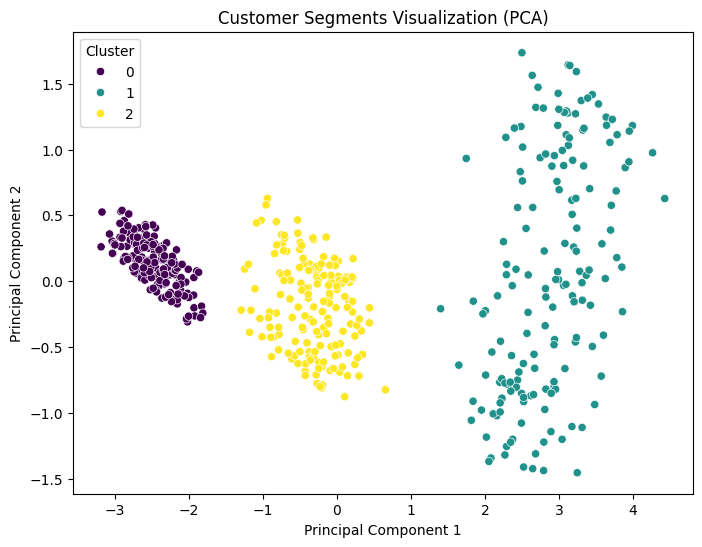

In [6]:
# 4. PCA
pca = PCA(n_components=2)
pca_transformed = pca.fit_transform(scaled_data)
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

# 5. Cluster Visualisation
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_transformed[:, 0], y=pca_transformed[:, 1], hue=df_cust['cluster'], palette='viridis')
plt.title('Customer Segments Visualization (PCA)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()